# 09 - Paper Case Comparisons

This notebook selects compact qualitative examples from the quantitative Pastor/SpeechXAI comparison.

For each dataset, it selects the best and worst per-audio performance difference against Pastor for:

- `level3`
- all LeGrad-HuBERT variants available in the quantitative result files

The selection criterion is:

```text
delta_vs_pastor = confidence_drop(method) - confidence_drop(Pastor/SpeechXAI)
```

Positive values mean the HuBERT explanation removed regions that reduced the model confidence more than Pastor/SpeechXAI for the same audio and same `k`.

Important label convention used here:

- `ground_truth_label`: the dataset annotation.
- `model_prediction_before_deletion`: the class predicted by HuBERT before any audio interval is removed.
- `explanation_target_label`: the class whose confidence drop is measured after deletion. In this evaluation, it is the model prediction before deletion, not necessarily the ground-truth label.

Therefore, each visualization explains the model's own decision for that audio. When `ground_truth_label` and `explanation_target_label` differ, the explanation is still about the model prediction, not about the dataset annotation.

For the visual comparison, each selected case must have saved interval rows for Pastor/SpeechXAI and for the compared method. An interval is a time segment of the audio, defined by `start` and `end` seconds, that was selected for deletion and drawn as a colored bar in the figure.

## Setup

The result ZIP files must be in the project root. They are read directly with `zipfile.open`, not extracted.

In [1]:
from pathlib import Path
import csv
import io
import sys
import zipfile

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import Audio, Markdown, display

# Some rows contain long serialized fields, so the default csv field limit is too small.
_field_limit = sys.maxsize
while True:
    try:
        csv.field_size_limit(_field_limit)
        break
    except OverflowError:
        _field_limit //= 10

ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

OUTPUT_DIR = ROOT / "results" / "pastor_case_visualizations"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for old_file in OUTPUT_DIR.glob("*"):
    if old_file.is_file():
        old_file.unlink()

PASTOR_METHOD = "speechxai_pastor_loo_words"
LEVEL3_METHOD = "level3"
LEGRAD_METHODS = [
    "legrad_final_score_relu_attention_gradient_mean_layers_source_tokens",
    "legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens",
    "legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens",
    "legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens",
]
METHODS_TO_COMPARE = [LEVEL3_METHOD, *LEGRAD_METHODS]
METHODS_FOR_FIGURE = [PASTOR_METHOD, *METHODS_TO_COMPARE]
VALID_K = [1, 2, 3, 5]

METHOD_LABELS = {
    PASTOR_METHOD: "Pastor/SpeechXAI",
    LEVEL3_METHOD: "Level 3",
    "legrad_final_score_relu_attention_gradient_mean_layers_source_tokens": "LeGrad final-score, mean layers",
    "legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens": "LeGrad final-score, HuBERT-weighted",
    "legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens": "LeGrad layer-local, mean layers",
    "legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens": "LeGrad layer-local, HuBERT-weighted",
}

IEMOCAP_SELECTED_COLUMNS = [
    "dataset", "audio_path", "audio_id", "relative_path", "true_class", "true_label",
    "session_id", "dialogue_id", "utterance_id", "iemocap_emotion", "annotation_path",
    "k", "method", "method_family", "selection", "random_trial", "requested_duration",
    "interval_rank", "start", "end", "score", "token_index", "word_index", "word",
]
RAVDESS_SELECTED_COLUMNS = [
    "dataset", "audio_path", "audio_id", "relative_path", "true_class", "true_label",
    "actor_id", "ravdess_emotion", "k", "method", "method_family", "selection",
    "random_trial", "requested_duration", "interval_rank", "start", "end", "score",
    "token_index", "word_index", "word",
]

SOURCES = {
    "IEMOCAP": {
        "zip": ROOT / "IEMOCAP_speech_xai_results_20260711_074459.zip",
        "root": "iemocap_ravdess_duration_matched_speechxai_20260710_194505_901788",
        "selected_columns": IEMOCAP_SELECTED_COLUMNS,
        "selected_header": None,
        "skip_leading_nulls": True,
        "note": "Partial IEMOCAP run; selected_intervals.csv has a large leading-NUL prefix.",
    },
    "RAVDESS": {
        "zip": ROOT / "RAVDESS_speech_xai_results_20260711_100706.zip",
        "root": "ravdess_duration_matched_speechxai_20260711_092556_063830",
        "selected_columns": RAVDESS_SELECTED_COLUMNS,
        "selected_header": 0,
        "skip_leading_nulls": False,
        "note": "Complete RAVDESS run.",
    },
}

missing = [str(source["zip"]) for source in SOURCES.values() if not source["zip"].exists()]
if missing:
    raise FileNotFoundError("Missing result ZIP file(s): " + ", ".join(missing))

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)


## Load Deletion Records

Only Pastor, Level 3, and the selected LeGrad-HuBERT method are needed for this case-selection notebook.

In [2]:
def read_csv_from_zip(zip_path: Path, inner_path: str, **kwargs) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as archive:
        with archive.open(inner_path) as handle:
            return pd.read_csv(handle, **kwargs)

records_usecols = [
    "dataset", "audio_path", "audio_id", "relative_path", "true_class", "true_label", "k", "method", "method_family", "selection",
    "requested_duration", "masked_duration", "original_label", "target_label",
    "original_confidence", "masked_confidence", "confidence_drop",
    "masked_predicted_label", "prediction_flipped", "token_count", "word_count",
]

record_frames = []
for dataset, source in SOURCES.items():
    records = read_csv_from_zip(
        source["zip"],
        f"{source['root']}/duration_matched_records.csv",
        usecols=records_usecols,
        dtype=str,
        low_memory=False,
    )
    records["dataset"] = records["dataset"].astype(str).str.strip()
    records["method"] = records["method"].astype(str).str.strip()
    records["selection"] = records["selection"].astype(str).str.strip()
    records["audio_id"] = records["audio_id"].astype(str).str.strip()
    records["audio_path"] = records["audio_path"].astype(str).str.strip()
    records["relative_path"] = records["relative_path"].astype(str).str.strip()
    records["true_label"] = records["true_label"].astype(str).str.strip()
    records["k"] = pd.to_numeric(records["k"], errors="coerce")
    for column in ["true_class", "requested_duration", "masked_duration", "original_confidence", "masked_confidence", "confidence_drop", "token_count", "word_count"]:
        records[column] = pd.to_numeric(records[column], errors="coerce")

    records = records[
        records["dataset"].eq(dataset)
        & records["k"].isin(VALID_K)
        & records["method"].isin(METHODS_FOR_FIGURE)
        & records["selection"].isin(["top_words", "top"])
    ].copy()
    records["k"] = records["k"].astype(int)
    record_frames.append(records)

records = pd.concat(record_frames, ignore_index=True)

records["ground_truth_label"] = records["true_label"]
records["model_prediction_before_deletion"] = records["original_label"]
records["explanation_target_label"] = records["target_label"]
records["explanation_target_is_ground_truth"] = records["explanation_target_label"].eq(records["ground_truth_label"])
records["explanation_target_is_model_prediction"] = records["explanation_target_label"].eq(records["model_prediction_before_deletion"])


record_summary = records.groupby(["dataset", "method", "selection"]).size().reset_index(name="rows")
display(record_summary)
display(Markdown("**Legend.** Rows are deletion-evaluation rows filtered to Pastor top words, Level 3 top tokens, and all LeGrad-HuBERT top tokens for `k in {1,2,3,5}`. The explanation target is the model prediction before deletion; the ground-truth label is shown separately."))


,dataset,method,selection,rows
0,IEMOCAP,legrad_final_score_relu_attention_gradient_mea...,top,21840
1,IEMOCAP,legrad_final_score_relu_attention_gradient_ren...,top,21840
2,IEMOCAP,legrad_layer_local_score_relu_attention_gradie...,top,21840
3,IEMOCAP,legrad_layer_local_score_relu_attention_gradie...,top,21840
4,IEMOCAP,level3,top,21839
5,IEMOCAP,speechxai_pastor_loo_words,top_words,21839
6,RAVDESS,legrad_final_score_relu_attention_gradient_mea...,top,2684
7,RAVDESS,legrad_final_score_relu_attention_gradient_ren...,top,2684
8,RAVDESS,legrad_layer_local_score_relu_attention_gradie...,top,2684
9,RAVDESS,legrad_layer_local_score_relu_attention_gradie...,top,2684


**Legend.** Rows are deletion-evaluation rows filtered to Pastor top words, Level 3 top tokens, and all LeGrad-HuBERT top tokens for `k in {1,2,3,5}`. The explanation target is the model prediction before deletion; the ground-truth label is shown separately.

## Find Saved Interval Keys

An interval row is one selected time span in the audio. It has `start` and `end` columns in seconds. Pastor/SpeechXAI intervals correspond to selected words; Level 3 and LeGrad intervals correspond to selected HuBERT time tokens.

The interval files are large, so this first pass stores only `(dataset, audio_id, k, method)` keys and interval counts. The full interval rows are loaded later only for the final selected cases.

In [3]:
SELECTED_INDEX = {
    "IEMOCAP": {
        "expected": 24,
        "dataset": 0,
        "audio_id": 2,
        "k": 11,
        "method": 12,
        "method_family": 13,
        "selection": 14,
        "requested_duration": 16,
        "interval_rank": 17,
        "start": 18,
        "end": 19,
        "score": 20,
        "token_index": 21,
        "word_index": 22,
        "word": 23,
    },
    "RAVDESS": {
        "expected": 21,
        "dataset": 0,
        "audio_id": 2,
        "k": 8,
        "method": 9,
        "method_family": 10,
        "selection": 11,
        "requested_duration": 13,
        "interval_rank": 14,
        "start": 15,
        "end": 16,
        "score": 17,
        "token_index": 18,
        "word_index": 19,
        "word": 20,
    },
}


def _iter_binary_csv_lines(handle, *, skip_leading_nulls: bool, chunk_size: int = 16 * 1024 * 1024):
    pending = b""
    started = not skip_leading_nulls
    while True:
        chunk = handle.read(chunk_size)
        if not chunk:
            break
        if not started:
            stripped = chunk.lstrip(b"\x00")
            if not stripped:
                continue
            chunk = stripped
            started = True
        data = pending + chunk
        lines = data.split(b"\n")
        pending = lines.pop()
        for line in lines:
            yield line.rstrip(b"\r")
    if pending:
        yield pending.rstrip(b"\r")


def _decode(value: bytes) -> str:
    return value.decode("utf-8", errors="ignore").strip()


def _float_from_bytes(value: bytes) -> float:
    try:
        return float(value.decode("ascii", errors="ignore"))
    except ValueError:
        return np.nan


def _parse_selected_interval_line(line: bytes, dataset: str):
    index = SELECTED_INDEX[dataset]
    parts = line.split(b",", index["expected"] - 1)
    if len(parts) < index["expected"]:
        return None

    dataset_value = _decode(parts[index["dataset"]])
    if dataset_value != dataset:
        return None
    method = _decode(parts[index["method"]])
    selection = _decode(parts[index["selection"]])
    if method not in METHODS_FOR_FIGURE or selection not in {"top_words", "top"}:
        return None

    k_float = _float_from_bytes(parts[index["k"]])
    if not np.isfinite(k_float):
        return None
    k = int(k_float)
    if k not in VALID_K:
        return None

    start = _float_from_bytes(parts[index["start"]])
    end = _float_from_bytes(parts[index["end"]])
    if not np.isfinite(start) or not np.isfinite(end) or end <= start:
        return None

    return {
        "dataset": dataset,
        "audio_id": _decode(parts[index["audio_id"]]),
        "k": k,
        "method": method,
        "method_family": _decode(parts[index["method_family"]]),
        "selection": selection,
        "requested_duration": _float_from_bytes(parts[index["requested_duration"]]),
        "interval_rank": _float_from_bytes(parts[index["interval_rank"]]),
        "start": start,
        "end": end,
        "score": _float_from_bytes(parts[index["score"]]),
        "token_index": _float_from_bytes(parts[index["token_index"]]),
        "word_index": _float_from_bytes(parts[index["word_index"]]),
        "word": _decode(parts[index["word"]]),
    }


def iter_selected_interval_rows(dataset: str):
    source = SOURCES[dataset]
    with zipfile.ZipFile(source["zip"]) as archive:
        with archive.open(f"{source['root']}/selected_intervals.csv") as handle:
            for line_number, line in enumerate(
                _iter_binary_csv_lines(handle, skip_leading_nulls=source.get("skip_leading_nulls", False)),
                start=1,
            ):
                if source["selected_header"] == 0 and line_number == 1:
                    continue
                row = _parse_selected_interval_line(line, dataset)
                if row is not None:
                    yield row


available_interval_keys = set()
interval_counts = {}
for dataset in SOURCES:
    for row in iter_selected_interval_rows(dataset):
        key = (row["dataset"], row["audio_id"], row["k"], row["method"])
        available_interval_keys.add(key)
        count_key = (row["dataset"], row["method"], row["selection"])
        interval_counts[count_key] = interval_counts.get(count_key, 0) + 1

interval_summary = pd.DataFrame(
    [
        {"dataset": dataset, "method": method, "selection": selection, "interval_rows": count}
        for (dataset, method, selection), count in interval_counts.items()
    ]
).sort_values(["dataset", "method", "selection"])
display(interval_summary)
display(Markdown("**Legend.** This table counts saved interval rows for each method. One interval row is one selected audio time span with `start` and `end` seconds. Pastor/SpeechXAI rows are word intervals; Level 3 and LeGrad rows are HuBERT token intervals. The IEMOCAP ZIP contains a large leading-NUL prefix, so this notebook uses a binary line reader that skips that prefix before parsing rows."))


,dataset,method,selection,interval_rows
2,IEMOCAP,legrad_final_score_relu_attention_gradient_mea...,top,70816
3,IEMOCAP,legrad_final_score_relu_attention_gradient_ren...,top,70816
4,IEMOCAP,legrad_layer_local_score_relu_attention_gradie...,top,70816
5,IEMOCAP,legrad_layer_local_score_relu_attention_gradie...,top,70816
1,IEMOCAP,level3,top,70816
0,IEMOCAP,speechxai_pastor_loo_words,top_words,4084
8,RAVDESS,legrad_final_score_relu_attention_gradient_mea...,top,125227
9,RAVDESS,legrad_final_score_relu_attention_gradient_ren...,top,125227
10,RAVDESS,legrad_layer_local_score_relu_attention_gradie...,top,125227
11,RAVDESS,legrad_layer_local_score_relu_attention_gradie...,top,125227


**Legend.** This table counts saved interval rows for each method. One interval row is one selected audio time span with `start` and `end` seconds. Pastor/SpeechXAI rows are word intervals; Level 3 and LeGrad rows are HuBERT token intervals. The IEMOCAP ZIP contains a large leading-NUL prefix, so this notebook uses a binary line reader that skips that prefix before parsing rows.

## Select Best And Worst Cases With Saved Intervals

For each dataset and method, the best case maximizes `delta_vs_pastor`; the worst case minimizes it.

The notebook keeps only cases where the interval file contains both sides of the comparison: Pastor/SpeechXAI intervals and intervals for our method. This is needed because the final figure draws both selections on the same audio timeline.

In [4]:
pastor = (
    records[records["method"].eq(PASTOR_METHOD)]
    [[
        "dataset", "audio_id", "k", "true_class", "true_label", "ground_truth_label", "model_prediction_before_deletion", "explanation_target_label", "explanation_target_is_ground_truth", "explanation_target_is_model_prediction", "target_label", "original_label", "original_confidence",
        "masked_confidence", "confidence_drop", "masked_predicted_label", "prediction_flipped",
        "requested_duration", "word_count", "token_count",
    ]]
    .rename(columns={
        "masked_confidence": "pastor_masked_confidence",
        "confidence_drop": "pastor_confidence_drop",
        "masked_predicted_label": "pastor_masked_predicted_label",
        "prediction_flipped": "pastor_prediction_flipped",
    })
)
method_rows = records[records["method"].isin(METHODS_TO_COMPARE)].copy()
paired = method_rows.merge(
    pastor,
    on=["dataset", "audio_id", "k"],
    how="inner",
    suffixes=("", "_pastor"),
)
paired["method_label"] = paired["method"].map(METHOD_LABELS)
paired["method_confidence_drop"] = paired["confidence_drop"]
paired["delta_vs_pastor"] = paired["method_confidence_drop"] - paired["pastor_confidence_drop"]
paired["delta_vs_pastor_percentage"] = np.where(
    paired["pastor_confidence_drop"].abs() > np.finfo(float).eps,
    100.0 * paired["delta_vs_pastor"] / paired["pastor_confidence_drop"].abs(),
    np.nan,
)
paired["beats_pastor"] = paired["delta_vs_pastor"] > 0

paired["has_pastor_intervals"] = [
    (row.dataset, row.audio_id, int(row.k), PASTOR_METHOD) in available_interval_keys
    for row in paired.itertuples(index=False)
]
paired["has_method_intervals"] = [
    (row.dataset, row.audio_id, int(row.k), row.method) in available_interval_keys
    for row in paired.itertuples(index=False)
]
cases_with_intervals = paired[paired["has_pastor_intervals"] & paired["has_method_intervals"]].copy()

case_rows = []
for (dataset, method), group in cases_with_intervals.groupby(["dataset", "method"], sort=True):
    best_row = group.sort_values("delta_vs_pastor", ascending=False).iloc[0].copy()
    best_row["case_type"] = "best"
    case_rows.append(best_row)

    worst_row = group.sort_values("delta_vs_pastor", ascending=True).iloc[0].copy()
    worst_row["case_type"] = "worst"
    case_rows.append(worst_row)

cases = pd.DataFrame(case_rows).reset_index(drop=True)
case_columns = [
    "dataset", "case_type", "method_label", "audio_id", "audio_path", "relative_path", "true_class", "ground_truth_label", "model_prediction_before_deletion", "explanation_target_label", "explanation_target_is_ground_truth", "k",
    "original_confidence", "pastor_masked_confidence", "masked_confidence",
    "pastor_confidence_drop", "method_confidence_drop", "delta_vs_pastor",
    "delta_vs_pastor_percentage", "beats_pastor", "pastor_prediction_flipped", "prediction_flipped",
]
cases[case_columns].to_csv(OUTPUT_DIR / "selected_paper_cases.csv", index=False)
display(cases[case_columns].sort_values(["dataset", "method_label", "case_type"]))
display(Markdown("**Legend.** `ground_truth_label` is the dataset annotation. `explanation_target_label` is the class whose confidence is measured before and after deletion; in this evaluation it is the model prediction before deletion. `best` is the largest positive difference versus Pastor/SpeechXAI; `worst` is the most negative difference."))


,dataset,case_type,method_label,audio_id,audio_path,relative_path,true_class,ground_truth_label,model_prediction_before_deletion,explanation_target_label,explanation_target_is_ground_truth,k,original_confidence,pastor_masked_confidence,masked_confidence,pastor_confidence_drop,method_confidence_drop,delta_vs_pastor,delta_vs_pastor_percentage,beats_pastor,pastor_prediction_flipped,prediction_flipped
2,IEMOCAP,best,"LeGrad final-score, HuBERT-weighted",Ses05M_script01_1_M020,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_script01_1/Ses05...,2.0,ang,ang,ang,True,5,0.964477,0.805192,0.128880,0.159285,0.835597,0.676312,424.593121,True,False,True
3,IEMOCAP,worst,"LeGrad final-score, HuBERT-weighted",Ses05M_impro07_M002,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_impro07/Ses05M_i...,1.0,hap,hap,hap,True,2,0.939220,0.208959,0.900679,0.730261,0.038541,-0.691720,-94.722238,False,True,False
0,IEMOCAP,best,"LeGrad final-score, mean layers",Ses05M_script01_1_M020,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_script01_1/Ses05...,2.0,ang,ang,ang,True,5,0.964477,0.805192,0.128880,0.159285,0.835597,0.676312,424.593121,True,False,True
1,IEMOCAP,worst,"LeGrad final-score, mean layers",Ses05M_impro07_M002,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_impro07/Ses05M_i...,1.0,hap,hap,hap,True,2,0.939220,0.208959,0.905532,0.730261,0.033688,-0.696573,-95.386829,False,True,False
6,IEMOCAP,best,"LeGrad layer-local, HuBERT-weighted",Ses05M_script03_2_M043,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_script03_2/Ses05...,2.0,ang,ang,ang,True,5,0.759160,0.820017,0.067568,-0.060857,0.691591,0.752449,1236.413473,True,False,True
7,IEMOCAP,worst,"LeGrad layer-local, HuBERT-weighted",Ses05M_impro07_M002,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_impro07/Ses05M_i...,1.0,hap,hap,hap,True,2,0.939220,0.208959,0.842954,0.730261,0.096266,-0.633995,-86.817577,False,True,False
4,IEMOCAP,best,"LeGrad layer-local, mean layers",Ses05M_script03_2_M043,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_script03_2/Ses05...,2.0,ang,ang,ang,True,5,0.759160,0.820017,0.090362,-0.060857,0.668798,0.729655,1198.959457,True,False,True
5,IEMOCAP,worst,"LeGrad layer-local, mean layers",Ses05M_impro07_M002,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_impro07/Ses05M_i...,1.0,hap,hap,hap,True,2,0.939220,0.208959,0.858175,0.730261,0.081045,-0.649216,-88.901860,False,True,False
8,IEMOCAP,best,Level 3,Ses05M_script02_2_M029,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_script02_2/Ses05...,3.0,sad,sad,sad,True,5,0.561908,0.911602,0.147930,-0.349695,0.413978,0.763673,218.382593,True,False,True
9,IEMOCAP,worst,Level 3,Ses05M_script01_1b_M022,/content/data/iemocap/extracted/IEMOCAP_full_r...,Session5/sentences/wav/Ses05M_script01_1b/Ses0...,2.0,ang,ang,ang,True,5,0.836257,0.073291,0.674129,0.762966,0.162129,-0.600838,-78.750243,False,True,False


**Legend.** `ground_truth_label` is the dataset annotation. `explanation_target_label` is the class whose confidence is measured before and after deletion; in this evaluation it is the model prediction before deletion. `best` is the largest positive difference versus Pastor/SpeechXAI; `worst` is the most negative difference.

## Load Intervals For Selected Cases

This second interval pass loads the actual `start` and `end` rows for the selected cases. These rows are the data used to draw the blue Pastor/SpeechXAI bars and the red HuBERT-method bars in the figure.

In [5]:
keys_to_load = set()
for case in cases.itertuples(index=False):
    keys_to_load.add((case.dataset, case.audio_id, int(case.k), PASTOR_METHOD))
    keys_to_load.add((case.dataset, case.audio_id, int(case.k), case.method))

selected_interval_rows = []
remaining_keys = set(keys_to_load)
for dataset in SOURCES:
    dataset_keys = {key for key in remaining_keys if key[0] == dataset}
    if not dataset_keys:
        continue
    for row in iter_selected_interval_rows(dataset):
        key = (row["dataset"], row["audio_id"], row["k"], row["method"])
        if key in dataset_keys:
            selected_interval_rows.append(row)
            remaining_keys.discard(key)
    if not any(key[0] == dataset for key in remaining_keys):
        continue

selected_intervals = pd.DataFrame(selected_interval_rows)
selected_intervals["method_label"] = selected_intervals["method"].map(METHOD_LABELS)
selected_intervals.to_csv(OUTPUT_DIR / "selected_paper_case_intervals.csv", index=False)

selected_interval_summary = selected_intervals.groupby(["dataset", "audio_id", "k", "method_label"]).size().reset_index(name="interval_rows")
display(selected_interval_summary)
display(Markdown("**Legend.** These are the exact interval rows used in the compact figures. Each row gives one selected time span through `start` and `end` seconds. Pastor/SpeechXAI rows are word intervals; Level 3 and LeGrad rows are HuBERT token intervals."))


,dataset,audio_id,k,method_label,interval_rows
0,IEMOCAP,Ses05M_impro07_M002,2,"LeGrad final-score, HuBERT-weighted",54
1,IEMOCAP,Ses05M_impro07_M002,2,"LeGrad final-score, mean layers",54
2,IEMOCAP,Ses05M_impro07_M002,2,"LeGrad layer-local, HuBERT-weighted",54
3,IEMOCAP,Ses05M_impro07_M002,2,"LeGrad layer-local, mean layers",54
4,IEMOCAP,Ses05M_impro07_M002,2,Pastor/SpeechXAI,2
5,IEMOCAP,Ses05M_script01_1_M020,5,"LeGrad final-score, HuBERT-weighted",77
6,IEMOCAP,Ses05M_script01_1_M020,5,"LeGrad final-score, mean layers",77
7,IEMOCAP,Ses05M_script01_1_M020,5,Pastor/SpeechXAI,5
8,IEMOCAP,Ses05M_script01_1b_M022,5,Level 3,50
9,IEMOCAP,Ses05M_script01_1b_M022,5,Pastor/SpeechXAI,5


**Legend.** These are the exact interval rows used in the compact figures. Each row gives one selected time span through `start` and `end` seconds. Pastor/SpeechXAI rows are word intervals; Level 3 and LeGrad rows are HuBERT token intervals.

## Separate Paper-Style Visualizations And Audio

The final figures are separated: one image per selected case. Each case also shows an audio player when the audio file exists in the local filesystem.

Blue bars are Pastor/SpeechXAI word intervals. The word text is centered above its own `start`-to-`end` interval. Red bars are HuBERT method token intervals. Each interval is a selected audio time span with `start` and `end` seconds.

The plot title reports both the dataset annotation and the class being explained. The class being explained is the HuBERT prediction before deletion.

### IEMOCAP - Level 3 - best - `Ses05M_script02_2_M029`

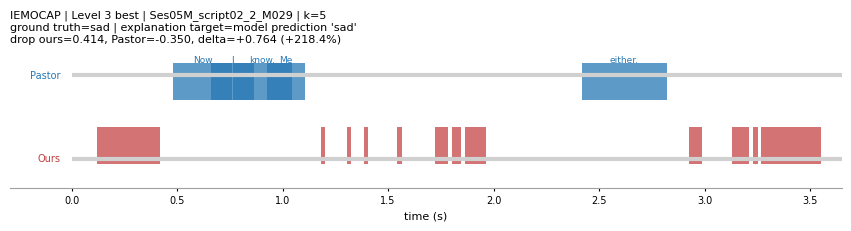

### IEMOCAP - Level 3 - worst - `Ses05M_script01_1b_M022`

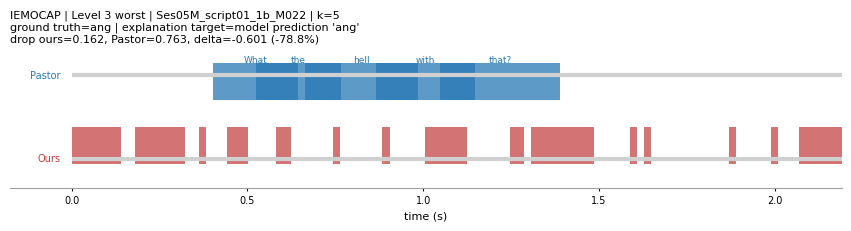

### IEMOCAP - LeGrad final-score, mean layers - best - `Ses05M_script01_1_M020`

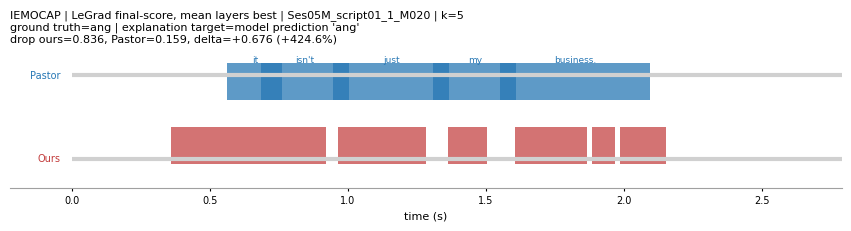

### IEMOCAP - LeGrad final-score, mean layers - worst - `Ses05M_impro07_M002`

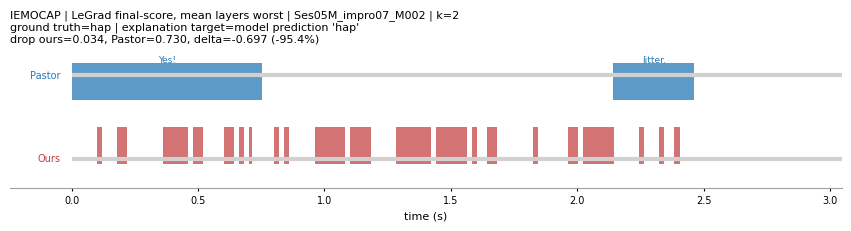

### IEMOCAP - LeGrad final-score, HuBERT-weighted - best - `Ses05M_script01_1_M020`

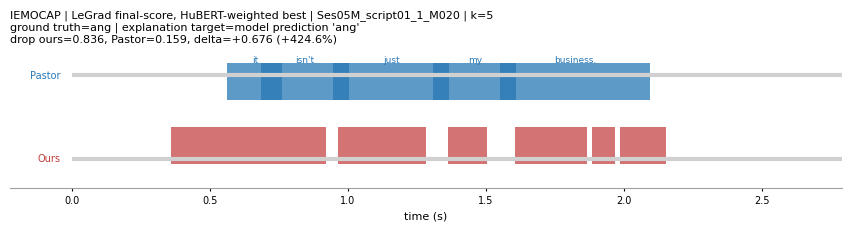

### IEMOCAP - LeGrad final-score, HuBERT-weighted - worst - `Ses05M_impro07_M002`

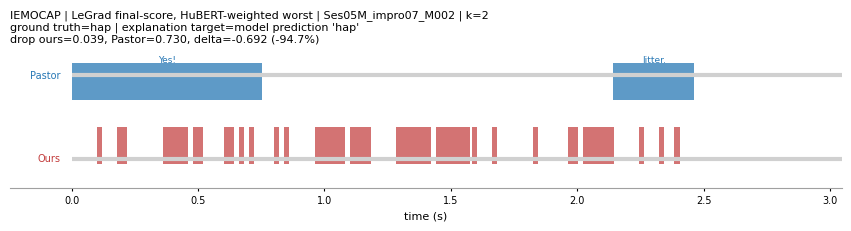

### IEMOCAP - LeGrad layer-local, mean layers - best - `Ses05M_script03_2_M043`

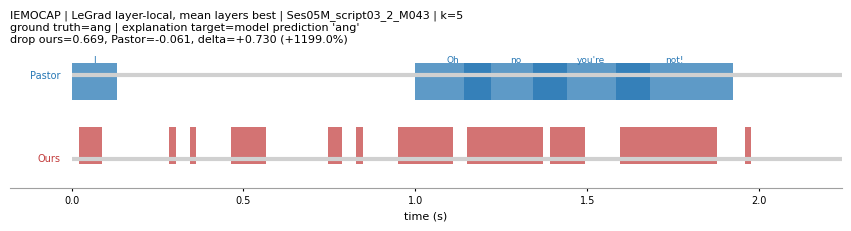

### IEMOCAP - LeGrad layer-local, mean layers - worst - `Ses05M_impro07_M002`

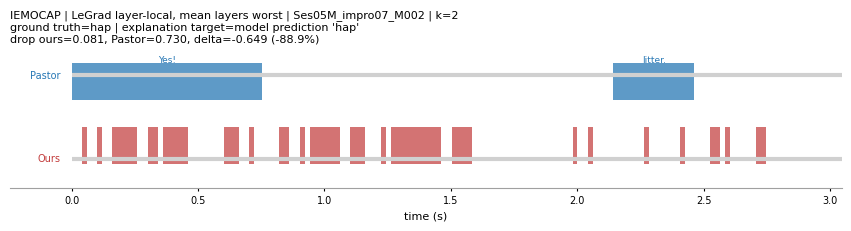

### IEMOCAP - LeGrad layer-local, HuBERT-weighted - best - `Ses05M_script03_2_M043`

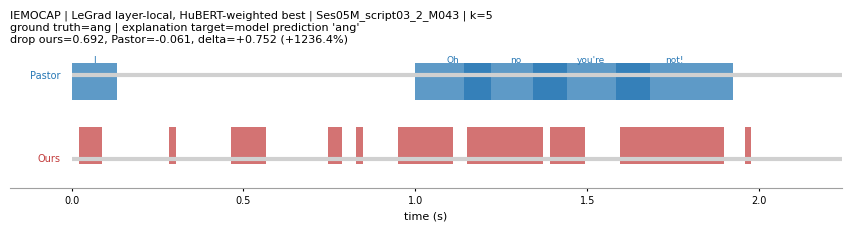

### IEMOCAP - LeGrad layer-local, HuBERT-weighted - worst - `Ses05M_impro07_M002`

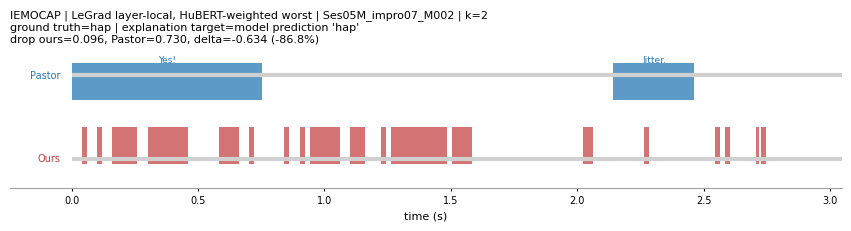

### RAVDESS - Level 3 - best - `03-01-05-02-02-02-06`

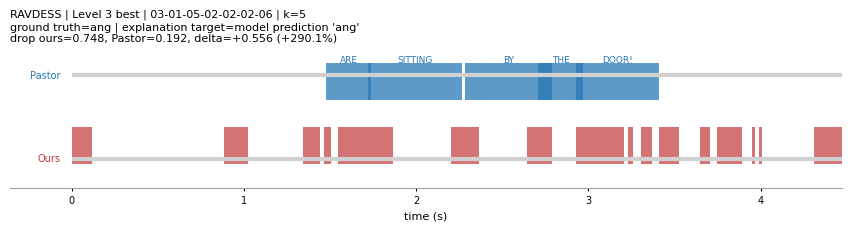

### RAVDESS - Level 3 - worst - `03-01-05-02-01-01-15`

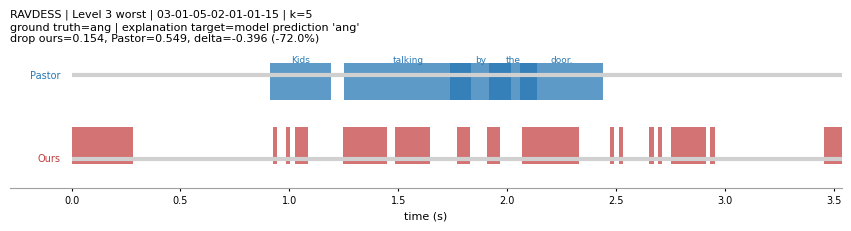

### RAVDESS - LeGrad final-score, mean layers - best - `03-01-05-01-01-01-09`

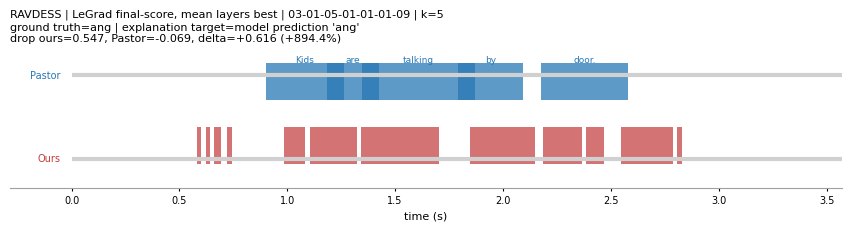

### RAVDESS - LeGrad final-score, mean layers - worst - `03-01-03-01-01-01-06`

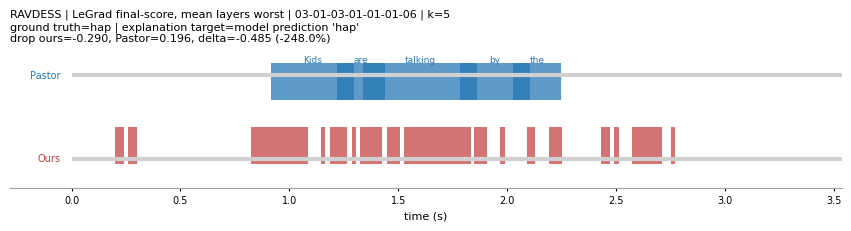

### RAVDESS - LeGrad final-score, HuBERT-weighted - best - `03-01-03-01-02-01-09`

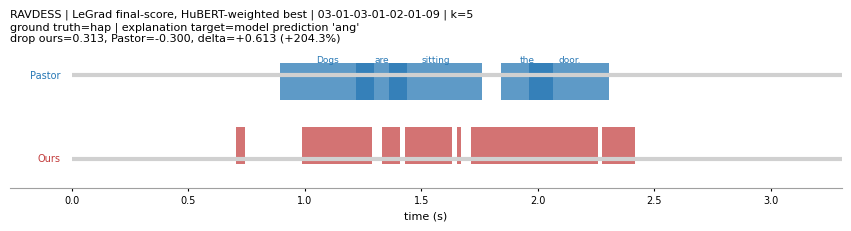

### RAVDESS - LeGrad final-score, HuBERT-weighted - worst - `03-01-01-01-01-02-09`

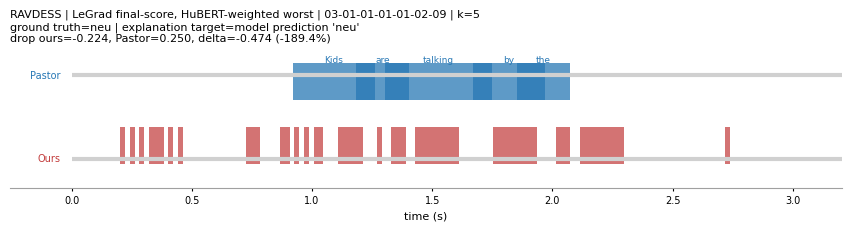

### RAVDESS - LeGrad layer-local, mean layers - best - `03-01-03-01-02-01-09`

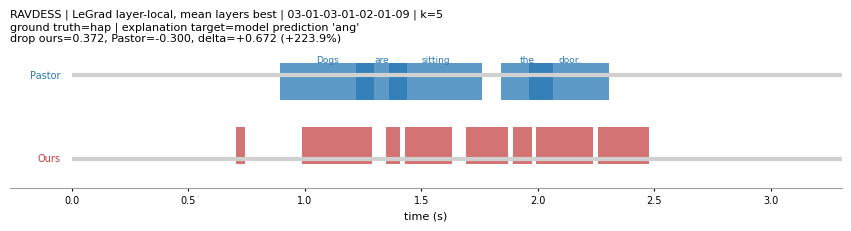

### RAVDESS - LeGrad layer-local, mean layers - worst - `03-01-05-02-01-02-16`

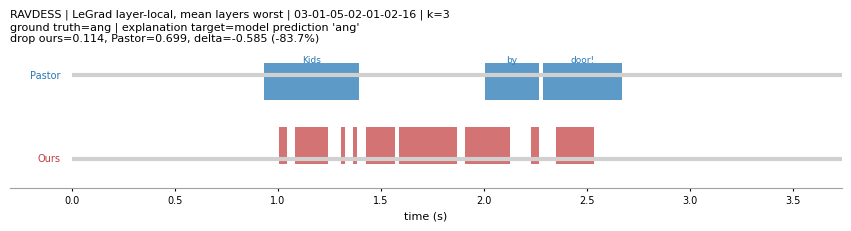

### RAVDESS - LeGrad layer-local, HuBERT-weighted - best - `03-01-03-01-02-01-09`

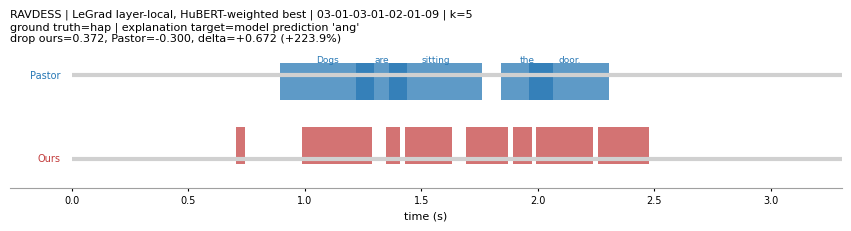

### RAVDESS - LeGrad layer-local, HuBERT-weighted - worst - `03-01-05-02-01-02-16`

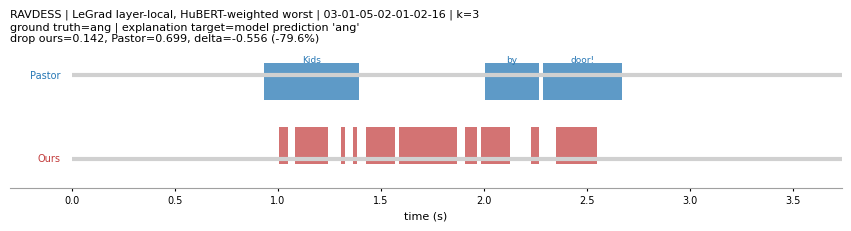

,dataset,method_label,case_type,audio_id,ground_truth_label,explanation_target_label,model_prediction_before_deletion,explanation_target_is_ground_truth,k,audio_path_found,figure_path
0,IEMOCAP,Level 3,best,Ses05M_script02_2_M029,sad,sad,sad,True,5,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
1,IEMOCAP,Level 3,worst,Ses05M_script01_1b_M022,ang,ang,ang,True,5,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
2,IEMOCAP,"LeGrad final-score, mean layers",best,Ses05M_script01_1_M020,ang,ang,ang,True,5,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
3,IEMOCAP,"LeGrad final-score, mean layers",worst,Ses05M_impro07_M002,hap,hap,hap,True,2,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
4,IEMOCAP,"LeGrad final-score, HuBERT-weighted",best,Ses05M_script01_1_M020,ang,ang,ang,True,5,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
5,IEMOCAP,"LeGrad final-score, HuBERT-weighted",worst,Ses05M_impro07_M002,hap,hap,hap,True,2,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
6,IEMOCAP,"LeGrad layer-local, mean layers",best,Ses05M_script03_2_M043,ang,ang,ang,True,5,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
7,IEMOCAP,"LeGrad layer-local, mean layers",worst,Ses05M_impro07_M002,hap,hap,hap,True,2,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
8,IEMOCAP,"LeGrad layer-local, HuBERT-weighted",best,Ses05M_script03_2_M043,ang,ang,ang,True,5,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...
9,IEMOCAP,"LeGrad layer-local, HuBERT-weighted",worst,Ses05M_impro07_M002,hap,hap,hap,True,2,C:\Users\mateu\repos\gradient_based_speach_xai...,C:\Users\mateu\repos\gradient_based_speach_xai...


[WindowsPath('C:/Users/mateu/repos/gradient_based_speach_xai/results/pastor_case_visualizations/iemocap_level_3_best_ses05m_script02_2_m029_k5.png'),
 WindowsPath('C:/Users/mateu/repos/gradient_based_speach_xai/results/pastor_case_visualizations/iemocap_level_3_worst_ses05m_script01_1b_m022_k5.png'),
 WindowsPath('C:/Users/mateu/repos/gradient_based_speach_xai/results/pastor_case_visualizations/iemocap_legrad_final-score__mean_layers_best_ses05m_script01_1_m020_k5.png'),
 WindowsPath('C:/Users/mateu/repos/gradient_based_speach_xai/results/pastor_case_visualizations/iemocap_legrad_final-score__mean_layers_worst_ses05m_impro07_m002_k2.png'),
 WindowsPath('C:/Users/mateu/repos/gradient_based_speach_xai/results/pastor_case_visualizations/iemocap_legrad_final-score__hubert-weighted_best_ses05m_script01_1_m020_k5.png'),
 WindowsPath('C:/Users/mateu/repos/gradient_based_speach_xai/results/pastor_case_visualizations/iemocap_legrad_final-score__hubert-weighted_worst_ses05m_impro07_m002_k2.png')

In [6]:
def _case_audio_duration(case: pd.Series, case_intervals: pd.DataFrame) -> float:
    method_intervals = case_intervals[case_intervals["method"].eq(case["method"])]
    widths = (method_intervals["end"] - method_intervals["start"]).dropna()
    widths = widths[widths > 0]
    if len(widths) and pd.notna(case.get("token_count")) and float(case["token_count"]) > 0:
        return float(np.median(widths) * float(case["token_count"]))
    if len(case_intervals):
        return float(case_intervals["end"].max())
    return 1.0


def _word_label(word: object, max_chars: int = 18) -> str:
    text = str(word).strip()
    if not text or text.lower() == "nan":
        return ""
    return text if len(text) <= max_chars else text[: max_chars - 1] + "..."


def _slug(value: str) -> str:
    allowed = []
    for character in str(value):
        if character.isalnum() or character in {"-", "_"}:
            allowed.append(character)
        else:
            allowed.append("_")
    return "".join(allowed).strip("_").lower()


def _candidate_relative_paths(case: pd.Series):
    candidates = []
    for column in ["relative_path", "audio_path"]:
        text = str(case.get(column, "")).strip()
        if not text or text.lower() == "nan":
            continue
        normalized = text.replace("\\", "/")
        candidates.append(Path(*[part for part in normalized.split("/") if part]))

        parts = [part for part in normalized.split("/") if part]
        for marker in ["IEMOCAP_full_release", "ravdess", "Audio_Speech_Actors_01-24"]:
            if marker in parts:
                marker_index = parts.index(marker)
                tail = parts[marker_index + 1 :]
                if tail:
                    candidates.append(Path(*tail))
    return candidates


def resolve_audio_path(case: pd.Series):
    audio_text = str(case.get("audio_path", "")).strip()
    direct_candidates = []
    if audio_text and audio_text.lower() != "nan":
        direct_candidates.append(Path(audio_text))

    search_roots = [
        ROOT,
        ROOT / "data",
        ROOT / "data" / "iemocap" / "extracted" / "IEMOCAP_full_release",
        ROOT / "data" / "ravdess",
        ROOT / "data" / "ravdess" / "Audio_Speech_Actors_01-24",
        Path("/content/data"),
        Path("/content/data/iemocap/extracted/IEMOCAP_full_release"),
        Path("/content/data/ravdess"),
        Path("/content/data/ravdess/Audio_Speech_Actors_01-24"),
    ]

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    for relative_path in _candidate_relative_paths(case):
        if relative_path.exists():
            return relative_path
        for root in search_roots:
            candidate = root / relative_path
            if candidate.exists():
                return candidate
    return None


def plot_single_case(case: pd.Series, intervals: pd.DataFrame) -> Path:
    dataset = case["dataset"]
    case_intervals = intervals[
        intervals["dataset"].eq(dataset)
        & intervals["audio_id"].astype(str).eq(str(case["audio_id"]))
        & intervals["k"].eq(int(case["k"]))
        & intervals["method"].isin([PASTOR_METHOD, case["method"]])
    ].copy()
    if case_intervals.empty:
        raise ValueError(f"No saved intervals found for {dataset} {case['audio_id']} k={case['k']}.")

    duration = _case_audio_duration(case, case_intervals)
    duration = max(duration, float(case_intervals["end"].max()))

    fig, axis = plt.subplots(1, 1, figsize=(8.4, 2.2), constrained_layout=True)
    pastor_color = "#2878B5"
    method_color = "#C33D3D"

    axis.hlines([1.0, 0.0], xmin=0, xmax=duration, color="#D0D0D0", linewidth=3)

    pastor_intervals = case_intervals[case_intervals["method"].eq(PASTOR_METHOD)].sort_values("start")
    for _, interval in pastor_intervals.iterrows():
        axis.axvspan(interval["start"], interval["end"], ymin=0.62, ymax=0.88, color=pastor_color, alpha=0.75, linewidth=0)
        word_label = _word_label(interval.get("word", ""))
        if word_label:
            midpoint = 0.5 * (float(interval["start"]) + float(interval["end"]))
            axis.text(
                midpoint,
                1.13,
                word_label,
                color=pastor_color,
                fontsize=6.5,
                ha="center",
                va="bottom",
                rotation=0,
                clip_on=False,
            )

    method_intervals = case_intervals[case_intervals["method"].eq(case["method"])]
    for _, interval in method_intervals.iterrows():
        axis.axvspan(interval["start"], interval["end"], ymin=0.17, ymax=0.43, color=method_color, alpha=0.72, linewidth=0)

    axis.text(-0.015 * duration, 1.0, "Pastor", ha="right", va="center", fontsize=7, color=pastor_color)
    axis.text(-0.015 * duration, 0.0, "Ours", ha="right", va="center", fontsize=7, color=method_color)

    title = (
        f"{dataset} | {case['method_label']} {case['case_type']} | {case['audio_id']} | k={int(case['k'])}\n"
        f"ground truth={case['ground_truth_label']} | explanation target=model prediction '{case['explanation_target_label']}'\n"
        f"drop ours={case['method_confidence_drop']:.3f}, Pastor={case['pastor_confidence_drop']:.3f}, "
        f"delta={case['delta_vs_pastor']:+.3f} ({case['delta_vs_pastor_percentage']:+.1f}%)"
    )
    axis.set_title(title, loc="left", fontsize=8.0, pad=3)
    axis.set_ylim(-0.35, 1.35)
    axis.set_xlim(-0.08 * duration, duration)
    axis.set_yticks([])
    axis.set_xlabel("time (s)", fontsize=8)
    axis.tick_params(axis="x", labelsize=7, length=2)
    axis.spines[["left", "right", "top"]].set_visible(False)
    axis.spines["bottom"].set_color("#A0A0A0")

    filename = "_".join([
        _slug(dataset),
        _slug(case["method_label"]),
        _slug(case["case_type"]),
        _slug(case["audio_id"]),
        f"k{int(case['k'])}",
    ]) + ".png"
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


ordered_cases = cases.copy()
ordered_cases["dataset_order"] = ordered_cases["dataset"].map({dataset: index for index, dataset in enumerate(SOURCES)})
ordered_cases["method_order"] = ordered_cases["method"].map({method: index for index, method in enumerate(METHODS_TO_COMPARE)})
ordered_cases["case_type_order"] = ordered_cases["case_type"].map({"best": 0, "worst": 1})
ordered_cases = ordered_cases.sort_values(["dataset_order", "method_order", "case_type_order"])

case_display_rows = []
figure_paths = []
for _, case_row in ordered_cases.iterrows():
    audio_path = resolve_audio_path(case_row)
    display(Markdown(f"### {case_row['dataset']} - {case_row['method_label']} - {case_row['case_type']} - `{case_row['audio_id']}`"))
    if audio_path is not None:
        display(Audio(filename=str(audio_path)))
        audio_display_path = str(audio_path)
    else:
        display(Markdown("Audio file not found locally. The figure is still generated from the saved interval rows. Put the dataset under `data/` or run this notebook in the Colab environment where the result paths exist to show the audio player."))
        audio_display_path = ""
    figure_path = plot_single_case(case_row, selected_intervals)
    figure_paths.append(figure_path)
    case_display_rows.append({
        "dataset": case_row["dataset"],
        "method_label": case_row["method_label"],
        "case_type": case_row["case_type"],
        "audio_id": case_row["audio_id"],
        "ground_truth_label": case_row["ground_truth_label"],
        "explanation_target_label": case_row["explanation_target_label"],
        "model_prediction_before_deletion": case_row["model_prediction_before_deletion"],
        "explanation_target_is_ground_truth": bool(case_row["explanation_target_is_ground_truth"]),
        "k": int(case_row["k"]),
        "audio_path_found": audio_display_path,
        "figure_path": str(figure_path),
    })

case_display_table = pd.DataFrame(case_display_rows)
case_display_table.to_csv(OUTPUT_DIR / "selected_paper_case_figures_and_audio.csv", index=False)
display(case_display_table)
figure_paths


## Files Written

The notebook writes:

- `selected_paper_cases.csv`
- `selected_paper_case_intervals.csv`
- `selected_paper_case_figures_and_audio.csv`
- one separated PNG per selected case

With two datasets, Level 3, and four LeGrad variants, the expected output is 20 separated PNGs.

In [7]:
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.name)


iemocap_legrad_final-score__hubert-weighted_best_ses05m_script01_1_m020_k5.png
iemocap_legrad_final-score__hubert-weighted_worst_ses05m_impro07_m002_k2.png
iemocap_legrad_final-score__mean_layers_best_ses05m_script01_1_m020_k5.png
iemocap_legrad_final-score__mean_layers_worst_ses05m_impro07_m002_k2.png
iemocap_legrad_layer-local__hubert-weighted_best_ses05m_script03_2_m043_k5.png
iemocap_legrad_layer-local__hubert-weighted_worst_ses05m_impro07_m002_k2.png
iemocap_legrad_layer-local__mean_layers_best_ses05m_script03_2_m043_k5.png
iemocap_legrad_layer-local__mean_layers_worst_ses05m_impro07_m002_k2.png
iemocap_level_3_best_ses05m_script02_2_m029_k5.png
iemocap_level_3_worst_ses05m_script01_1b_m022_k5.png
ravdess_legrad_final-score__hubert-weighted_best_03-01-03-01-02-01-09_k5.png
ravdess_legrad_final-score__hubert-weighted_worst_03-01-01-01-01-02-09_k5.png
ravdess_legrad_final-score__mean_layers_best_03-01-05-01-01-01-09_k5.png
ravdess_legrad_final-score__mean_layers_worst_03-01-03-01-01